In questo esercizio si studia il clustering spaziale di un file fits proveniente dal catalogo: https://data.desi.lbl.gov/public/dr1/survey/catalogs/dr1/LSS/iron/LSScats/v1.5/ , da cui si prendono i dati RA&DEC,redshift e pesi per convertire coord. equatoriali in comoventi, calcolare le funzioni di correlazioni a due punti con Corrfunc ed infine confrontare i risultati con dati "rubati" dal paper https://arxiv.org/pdf/2411.12020 (si è analizzata la figura 15 a sinistra).

In [ ]:
from astropy.io import fits
import numpy as np
import sys
sys.path.append("../../")

from pyACC.fits_wrapper import FitsManager  

In [45]:
input_file="BGS_BRIGHT-21.5_NGC_clustering.dat.fits"
desi_catalogue=FitsManager(input_file)

2025-06-20 17:02:16.802642 :: FitsManager :: INFO :: Fits open succesfully


In [46]:
desi_catalogue.get_hdu_count()

2

In [47]:
data=desi_catalogue.get_data(1) # Prendo i dati dal secondo HDU (indice 1)
header=desi_catalogue.get_header(1)
header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  117 / length of dimension 1                          
NAXIS2  =               217614 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
TTYPE1  = 'TARGETID'                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'Z       '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'NTILE   '        

In [48]:
# Estraggo colonne principali: ascensione, declinazione, redshift e peso
ra,dec,redshift,weight=  data['RA'],data['DEC'],data['Z'],data['WEIGHT']

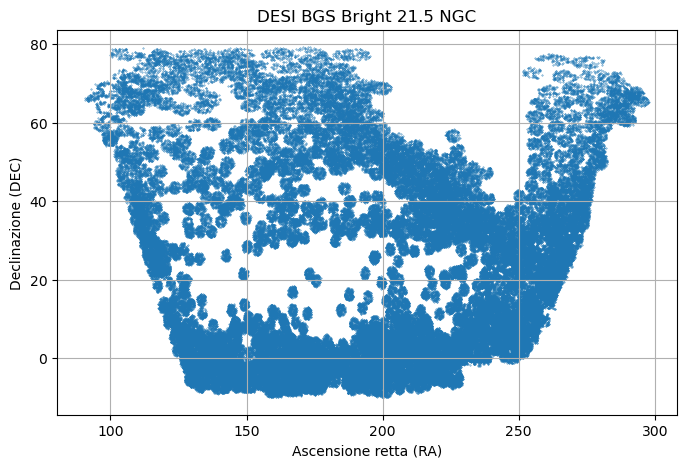

In [ ]:
import matplotlib.pyplot as plt # 
plt.figure(figsize=(8,5))
plt.scatter(ra,dec,s=0.1)
plt.xlabel("Ascensione retta (RA)")
plt.ylabel("Declinazione (DEC)")
plt.title
plt.grid(True)
plt.show()

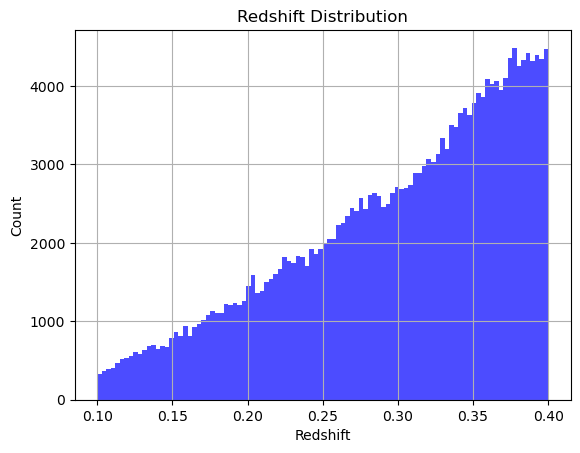

In [50]:
plt.hist(redshift, bins=100, color='blue', alpha=0.7) # Faccio un'istogramma del redshift
plt.xlabel("Redshift")
plt.ylabel("Count")
plt.title("Redshift Distribution")
plt.grid(True)
plt.show()

In [51]:
# Rileggo le colonne principali, anche i pesi
data_ra,data_dec,data_redshift,data_weight=data['RA'],data['DEC'],data['Z'],data['WEIGHT']

In [ ]:
# Leggo i dati dal file random
input_file_ran="BGS_BRIGHT-21.5_NGC_17_clustering.ran.fits"
desi_catalogue_random=FitsManager(input_file_ran)
rand_ra,rand_dec,rand_redshift,rand_weight=desi_catalogue_random.get_data(1)['RA'],desi_catalogue_random.get_data(1)['DEC'],desi_catalogue_random.get_data(1)['Z'],desi_catalogue_random.get_data(1)['WEIGHT']

# Prendo un sottocatalogo casuale di elementi dal catalogo random, che ha la stessa dimensione del catalogo vero
random_idx=np.random.choice(len(rand_ra),size=len(ra),replace=False) #choice estrae a casa da degli array 
rand_ra=rand_ra[random_idx] 
rand_dec=rand_dec[random_idx]
rand_redshift=rand_redshift[random_idx]
rand_weight=rand_weight[random_idx]
len(rand_ra),len(rand_dec),len(rand_redshift)

2025-06-20 17:02:17.223786 :: FitsManager :: INFO :: Fits open succesfully


(217614, 217614, 217614)

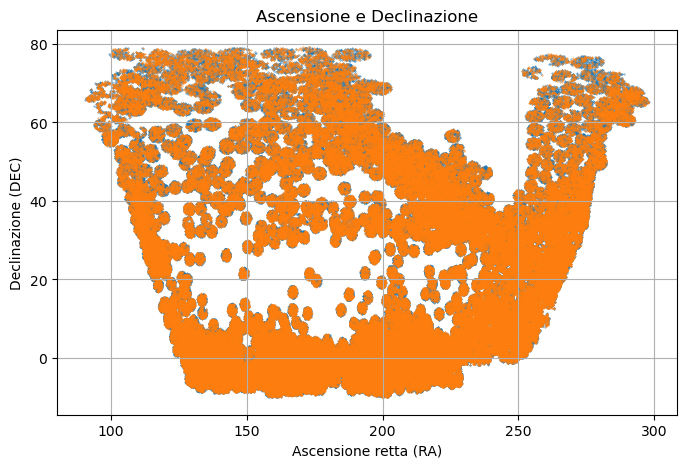

In [ ]:
# visualizzo a confronto galassie vere e random
plt.figure(figsize=(8,5))
plt.scatter(rand_ra,rand_dec,s=0.1, colorizer='blue')
plt.scatter(data_ra,data_dec,s=0.1, colorizer='red')
plt.xlabel("Ascensione retta (RA)")
plt.ylabel("Declinazione (DEC)")
plt.title("Ascensione e Declinazione dei due cataloghi")
plt.grid(True)
plt.show()

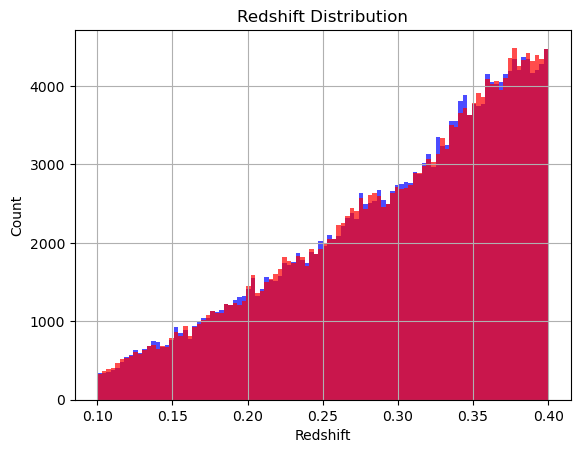

In [54]:
plt.hist(rand_redshift, bins=100, color='blue', alpha=0.7)
plt.hist(data_redshift, bins=100, color='red', alpha=0.7)
plt.xlabel("Redshift")
plt.ylabel("Count")
plt.title("Redshift Distribution")
plt.grid(True)
plt.show()

In [ ]:
#convert to comoving coordinates
from astropy.cosmology import FlatLambdaCDM
def equatorial_to_comoving(ra, dec, redshift,Om0):
    """
    Converte coordinate equatoriali (RA, DEC) e redshift in coordinate comoventi (x, y, z).
    """
    cosmo = FlatLambdaCDM(H0=100, Om0=0.3)  
    comoving_distance = cosmo.comoving_distance(redshift)   
    
    return comoving_distance.value * np.cos(np.radians(dec)) * np.cos(np.radians(ra)), \
           comoving_distance.value * np.cos(np.radians(dec)) * np.sin(np.radians(ra)), \
           comoving_distance.value * np.sin(np.radians(dec))

In [ ]:
# Applico conversione ai dati del catalogo vero e a quelli del catalogo random
omega_matter = 0.3
data_x, data_y, data_z = equatorial_to_comoving(ra, dec, redshift, omega_matter)
rand_x,rand_y,rand_z = equatorial_to_comoving(rand_ra, rand_dec, rand_redshift, omega_matter)

In [ ]:
import Corrfunc   # Libreria per correlazioni
from Corrfunc.theory import DD  
r_min=0.1
r_max=150
bin_size=5

r_edges = np.arange(r_min, r_max+bin_size, bin_size)  # Contiene le estremi dei bin
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])  # Contiene i centri dei bin

In [ ]:
# Calcolo la funzione di correlazione per il catalogo vero: conta quante coppie di galassie reali ci sono a diverse distanze
DD=Corrfunc.theory.DD(  
    autocorr=True, 
    nthreads=4, # Numero di thread,ovvero processi, per il calcolo parallelo
    binfile=r_edges, # File contenente le estremi dei bin
    X1=data_x, # Coordinate x del primo catalogo
    Y1=data_y,
    Z1=data_z,
    periodic=False,  
    verbose=True,   
    weight_type='pair_product',  # Usa il prodotto dei pesi
    weights1=data_weight.tolist()     # Pesi del primo catalogo
)


In [ ]:
# Calcolo la funzione di correlazione per il catalogo random, senza clustering
RR=Corrfunc.theory.DD(
    autocorr=True,
    nthreads=4,
    binfile=r_edges,
    X1=rand_x,
    Y1=rand_y,
    Z1=rand_z,
    periodic=False,
    verbose=True,
    weight_type='pair_product',
    weights1=rand_weight.tolist()  
)

In [ ]:
# Calcolo la funzione di correlazione per il catalogo vero e il catalogo random
DR=Corrfunc.theory.DD(
    autocorr=False,
    nthreads=4,
    binfile=r_edges,
    X1=data_x,
    Y1=data_y,
    Z1=data_z,
    X2=rand_x,
    Y2=rand_y,
    Z2=rand_z,
    periodic=False,
    verbose=True,
    weight_type='pair_product',
    weights1=data_weight.tolist(),
    weights2=rand_weight.tolist()
)

In [ ]:
from Corrfunc.utils import convert_3d_counts_to_cf  

# Calcolo la funzione di correlazione xi(r) usando l’estimatore di Landy-Szalay
xi=convert_3d_counts_to_cf(len(data_x), len(data_x), len(rand_x), len(rand_x),DD,DR,DR,RR,estimator='LS')

In [ ]:
# Calcolo manuale della funzione xi(r) per verifica
DD_norm=DD['npairs']*DD['weightavg']/np.sum(data_weight)**2
RR_norm=RR['npairs']*RR['weightavg']/np.sum(rand_weight)**2
DR_norm=DR['npairs']*DR['weightavg']/(np.sum(data_weight)*np.sum(rand_weight))
my_xi=(DD_norm-2*DR_norm+RR_norm)/RR_norm

# NB:'weightavg'= media dei prodotti dei pesi

In [ ]:
# Dati digitalizzati da un grafico di un paper (es. Fig. 15 di DESI): s=lista di distanze in Mpc/h, s2xi=lista dei valori xi*r^2 corrispondenti
s = [22.07520600558678, 26.2534785865071, 30.222832756727904, 33.98328445509419, 38.161557036014514, 41.922008734380796, 46.30919175657813, 50.06962751609943, 54.45682647714176, 58.21726223666305, 62.186624376306355, 65.5292392532736, 69.91642227547095, 74.51253167779029, 77.43732567220351, 81.61559825312384, 85.58494445392216, 89.55430659356546, 93.73257917448578, 98.11976219668311, 101.67130345377238, 105.01391833073964, 110.65457993944408, 113.99721075525632, 117.75764651477762, 121.72700865442091, 126.11419167661826, 130.08355381626154, 133.63507913450584, 137.60444127414914, 141.57380341379246, 145.54316555343576, 148.885780430403, 153.8997107152764, 157.8690728549197, 161.42059817316397, 165.59888669292928, 169.98605377628164, 173.7465054746479, 177.71585167544623, 181.4763033738125, 186.28132321740887, 189.6239540332211, 193.38437385389742, 197.98049919506175]
s2xi = [92.88537883146178, 89.32806070826561, 84.58496736436169, 81.02767185794671, 73.51778474357886, 63.24111139767411, 63.636369804576695, 56.52174109711141, 51.778662831061624, 52.56917210593972, 44.664034123596345, 38.33992976886328, 37.94466382303364, 29.249009026885105, 26.086956849518558, 17.391302053370012, 25.296440035713402, 17.391302053370012, 20.158103362761054, 24.505938299762377, 26.87747366332374, 24.901189167737883, 30.03952584069026, 33.59684396388644, 5.928861025684597, -8.69564725722148, -22.529668882030634, -22.92490467215204, -35.57311338161813, -34.78259656781299, -26.482237873202337, -15.019751611954533, -15.810268425759702, -7.905130443416326, -16.600785239564857, -19.76283741693139, -24.505953377616507, -34.78259656781299, -43.87351730979117, -66.40314849718646, -80.63240591211704, -94.86164824919348, -85.77075766292359, -82.60869040770294, -61.66007777006374]

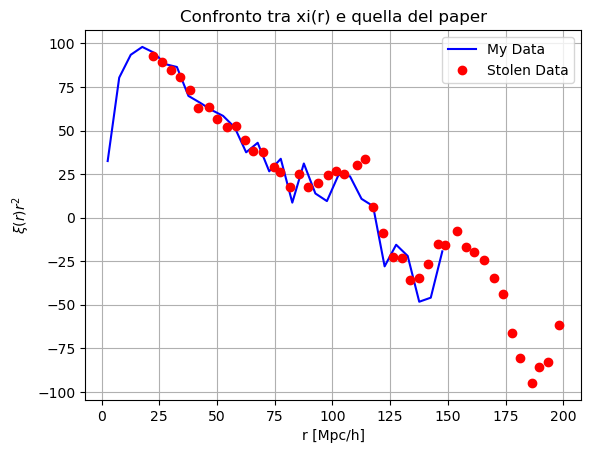

In [ ]:
plt.plot(r_centers,r_centers**2 *my_xi, label='My Data', color='blue')
plt.plot(s,s2xi,"o",label='Stolen Data', color='red')
plt.xlabel("r [Mpc/h]")  # Distanza spaziale r tra coppie di galassie
plt.ylabel(r"$\xi(r) r^2$")
plt.legend()
plt.grid(True)
plt.title("Confronto tra xi(r) e quella del paper")
plt.show()